In [2]:
# ==============================
# 1. INSTALL DEPENDENCIES
# ==============================
!pip install -q lightgbm catboost imbalanced-learn xgboost scikit-learn pandas numpy openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.8 MB/s eta 0:00:00


In [3]:
# ==============================
# 2. IMPORT LIBRARIES
# ==============================
import pandas as pd
import numpy as np
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, matthews_corrcoef, cohen_kappa_score, confusion_matrix)

from imblearn.metrics import geometric_mean_score
from imblearn.over_sampling import ADASYN
from catboost import CatBoostClassifier

from sklearn.linear_model import LogisticRegression

In [4]:
# ==============================
# 3. LOAD DATASET
# ==============================
df = pd.read_csv('/content/bank-additional-full.csv', sep=';')

In [5]:
# ==============================
# 4. PREPROCESSING
# ==============================
df = df.drop('duration', axis=1)

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace('unknown', df[col].mode()[0])

df['y'] = df['y'].map({'no': 0, 'yes': 1})

df = pd.get_dummies(df, drop_first=True)

In [6]:
# ==============================
# 5. SPLIT DATA
# ==============================
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [7]:
# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [8]:
# ADASYN
adasyn = ADASYN(random_state=42)
X_train_ad, y_train_ad = adasyn.fit_resample(X_train_scaled, y_train)


In [9]:
# ==============================
# 6. METRIC FUNCTIONS
# ==============================
def compute_metrics(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    print(f"Accuracy    : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision   : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall      : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Specificity : {tn / (tn + fp):.4f}")
    print(f"F1 Score    : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC-AUC     : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"MCC         : {matthews_corrcoef(y_true, y_pred):.4f}")
    print(f"G-Mean      : {geometric_mean_score(y_true, y_pred):.4f}")
    print(f"Kappa       : {cohen_kappa_score(y_true, y_pred):.4f}")

# **CatBoostClassifier**

In [10]:
# ==============================
# 7. HYPERPARAMETER TUNING
# ==============================
params = {
    "iterations":[400,600],
    "depth":[4,5],
    "learning_rate":[0.03],
    "class_weights":[[1,2],[1,3]]
}

cv_small = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rscv = RandomizedSearchCV(
    CatBoostClassifier(verbose=0),
    params,
    n_iter=5,
    scoring='f1',
    cv=cv_small,
    n_jobs=-1
)

rscv.fit(X_train_ad, y_train_ad)
best = rscv.best_estimator_

print("🔥 Tuned Model Performance (Test Set)")
y_pred = best.predict(X_test_scaled)
y_prob = best.predict_proba(X_test_scaled)[:,1]
compute_metrics(y_test, y_pred, y_prob)

print("Best Params:", rscv.best_params_)


🔥 Tuned Model Performance (Test Set)
Accuracy    : 0.8891
Precision   : 0.5070
Recall      : 0.5485
Specificity : 0.9323
F1 Score    : 0.5269
ROC-AUC     : 0.8094
MCC         : 0.4646
G-Mean      : 0.7151
Kappa       : 0.4642
Best Params: {'learning_rate': 0.03, 'iterations': 400, 'depth': 5, 'class_weights': [1, 2]}


In [12]:
# ==============================
# 8. CROSS VALIDATION (MAIN)
# ==============================
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

In [13]:
results1 = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train_f, X_test_f = X.iloc[train_idx], X.iloc[test_idx]
    y_train_f, y_test_f = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train_f = scaler.fit_transform(X_train_f)
    X_test_f  = scaler.transform(X_test_f)

    # ADASYN
    adasyn = ADASYN(random_state=42)
    X_train_f, y_train_f = adasyn.fit_resample(X_train_f, y_train_f)

    # Train
    start_time = time.time()
    best.fit(X_train_f, y_train_f)
    training_time = time.time() - start_time

    # Predict
    y_pred = best.predict(X_test_f)
    y_prob = best.predict_proba(X_test_f)[:,1]

    # Metrics
    acc = accuracy_score(y_test_f, y_pred)
    prec = precision_score(y_test_f, y_pred, zero_division=0)
    rec = recall_score(y_test_f, y_pred, zero_division=0)
    f1 = f1_score(y_test_f, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test_f, y_pred).ravel()

    specificity = tn/(tn+fp)
    fpr = fp/(fp+tn)
    gm = np.sqrt(rec * specificity)

    auc = roc_auc_score(y_test_f, y_prob)
    mcc = matthews_corrcoef(y_test_f, y_pred)
    kappa = cohen_kappa_score(y_test_f, y_pred)
    balanced_acc = (rec + specificity)/2

    results1.append({
        "Fold": fold+1,
        "Classifier": "CatBoost",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

In [14]:
# ==============================
# 9. PRINT RESULTS
# ==============================
df_results = pd.DataFrame(results1)

print("\n===== Fold Results =====")
print(df_results.to_string(index=False))

print("\n===== Average Results =====")
print(df_results.mean(numeric_only=True))


# ==============================
# 10. SAVE TO EXCEL
# ==============================
df_results.to_excel("catboost_results.xlsx", index=False)

print("\n✅ Results saved to catboost_results.xlsx")


===== Fold Results =====
 Fold Classifier  Accuracy  Precision   Recall  Specificity       F1       GM      FPR      AUC      MCC    Kappa  Balanced Accuracy  Training Time (s)
    1   CatBoost  0.879582   0.468000 0.504310     0.927223 0.485477 0.683819 0.072777 0.796765 0.417770 0.417397           0.715767          15.401534
    2   CatBoost  0.875455   0.451292 0.489224     0.924487 0.469493 0.672519 0.075513 0.786692 0.399486 0.399069           0.706856          11.661600
    3   CatBoost  0.873513   0.446729 0.515086     0.919015 0.478478 0.688020 0.080985 0.799213 0.408256 0.406921           0.717051          11.661103
    4   CatBoost  0.876669   0.456863 0.502155     0.924213 0.478439 0.681248 0.075787 0.783601 0.409269 0.408682           0.713184          11.852357
    5   CatBoost  0.882010   0.478846 0.536638     0.925855 0.506098 0.704875 0.074145 0.809210 0.440266 0.439346           0.731246          11.652472
    6   CatBoost  0.888080   0.502982 0.545259     0.931601 0.


--- SHAP EXPLANATION ---


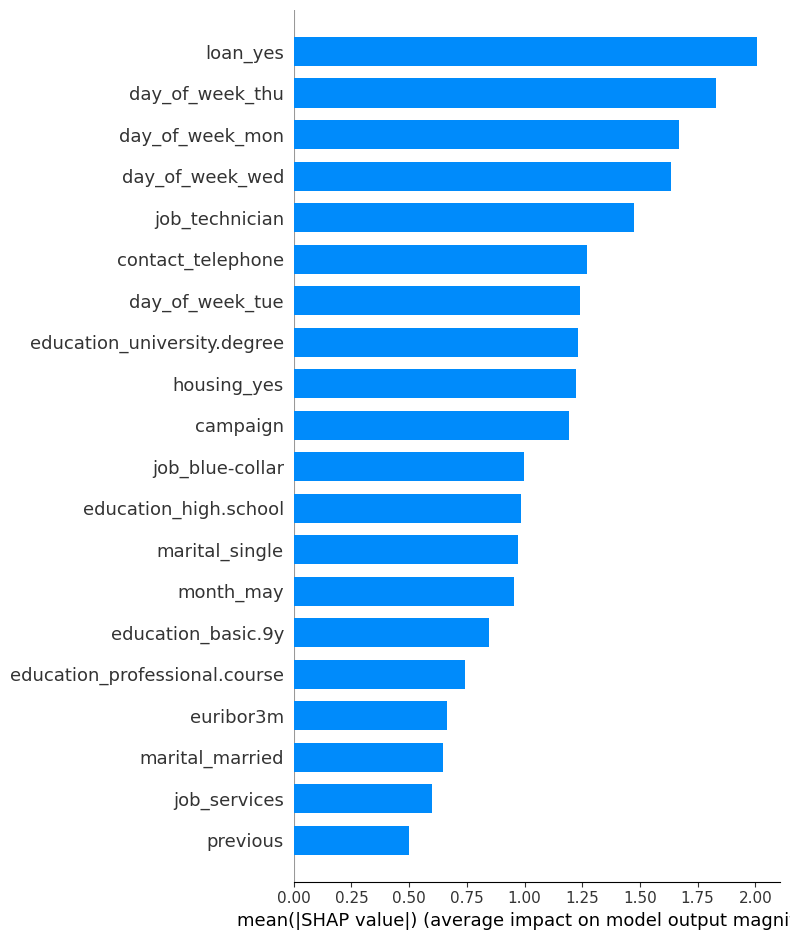

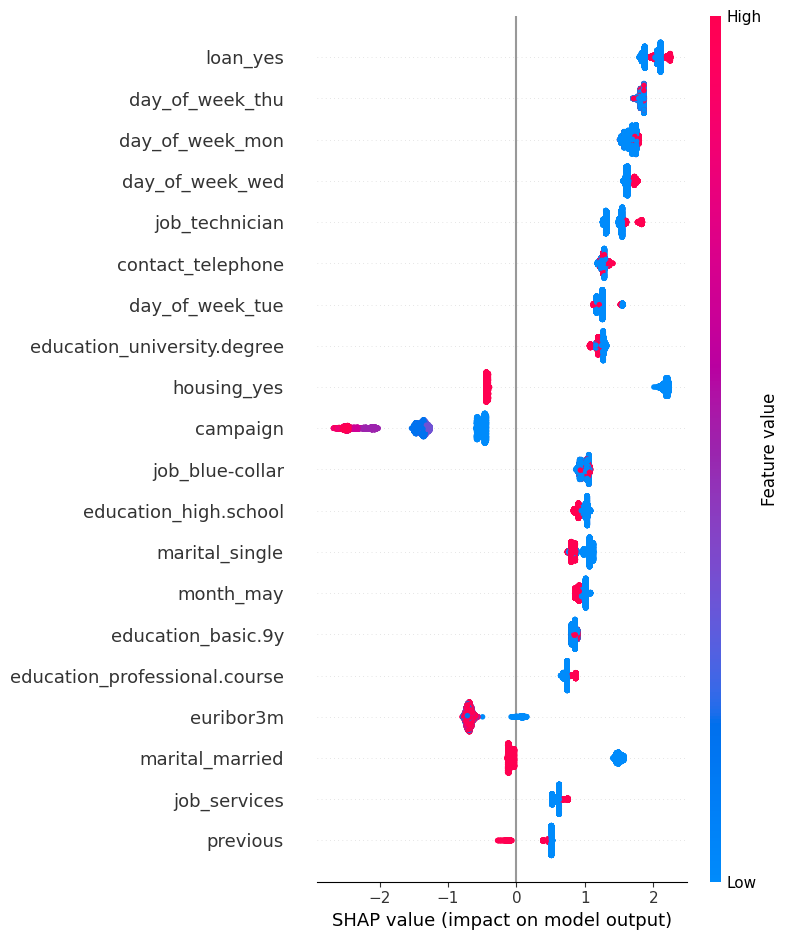

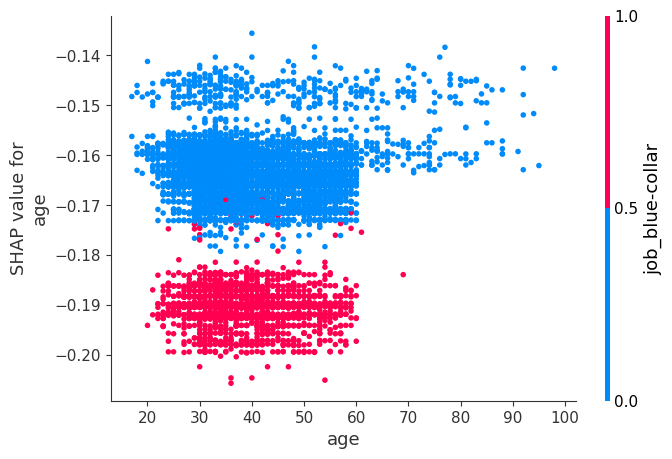

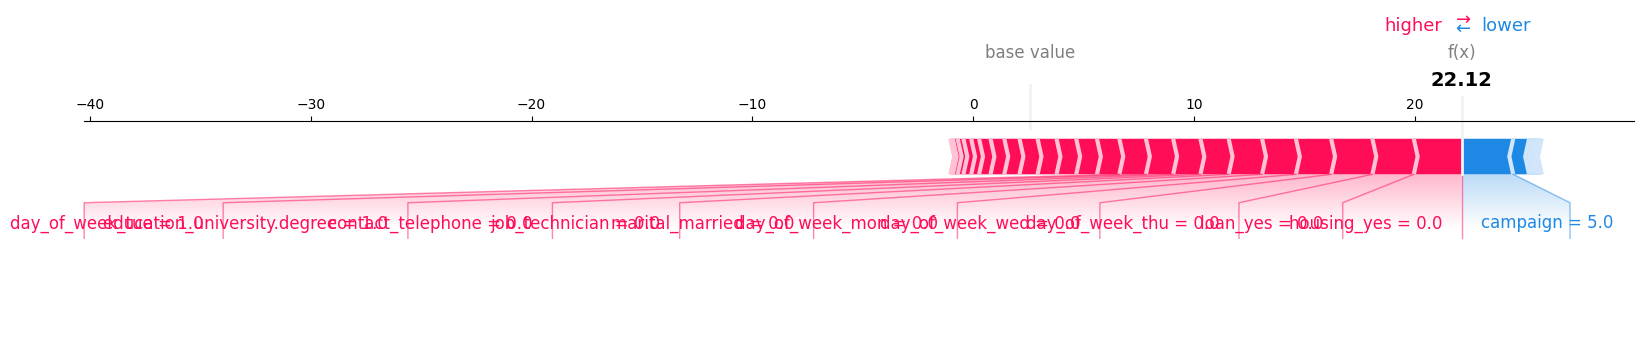

In [15]:
# ==============================
# SHAP EXPLAINABILITY (FINAL FIX)
# ==============================

print("\n--- SHAP EXPLANATION ---")

import shap
import matplotlib.pyplot as plt

# Explainer
explainer = shap.TreeExplainer(best)

# SHAP values
shap_values = explainer.shap_values(X_test)

# ✅ Handle classification
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY PLOT
# -------------------------------
shap.summary_plot(shap_values_class1, X_test)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
shap.dependence_plot(
    X_test.columns[0],
    shap_values_class1,
    X_test
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

shap.force_plot(
    base_value,
    shap_values_class1[0],
    X_test.iloc[0],
    matplotlib=True
)

# **LightGBM**

In [23]:
from lightgbm import LGBMClassifier

In [24]:
# ==============================
# LIGHTGBM TUNING
# ==============================
params_lgb = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "num_leaves": [31, 50],
    "max_depth": [-1, 10],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

rscv_lgb = RandomizedSearchCV(
    LGBMClassifier(class_weight='balanced'),
    params_lgb,
    n_iter=10,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

rscv_lgb.fit(X_train_ad, y_train_ad)

best_lgb = rscv_lgb.best_estimator_

[LightGBM] [Info] Number of positive: 29184, number of negative: 29238
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.020286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8217
[LightGBM] [Info] Number of data points in the train set: 58422, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


In [25]:
print("\n LightGBM (Tuned)")

y_pred_lgb = best_lgb.predict(X_test_scaled)
y_prob_lgb = best_lgb.predict_proba(X_test_scaled)[:,1]

compute_metrics(y_test, y_pred_lgb, y_prob_lgb)

print("Best Params (LGB):", rscv_lgb.best_params_)


 LightGBM (Tuned)
Accuracy    : 0.9020
Precision   : 0.6330
Recall      : 0.3103
Specificity : 0.9772
F1 Score    : 0.4165
ROC-AUC     : 0.8026
MCC         : 0.3979
G-Mean      : 0.5507
Kappa       : 0.3698
Best Params (LGB): {'subsample': 1.0, 'num_leaves': 50, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.8}


In [26]:
results_lgb = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train_f, X_test_f = X.iloc[train_idx], X.iloc[test_idx]
    y_train_f, y_test_f = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling (optional but keeping consistent)
    scaler = StandardScaler()
    X_train_f = scaler.fit_transform(X_train_f)
    X_test_f  = scaler.transform(X_test_f)

    # ADASYN
    adasyn = ADASYN(random_state=42)
    X_train_f, y_train_f = adasyn.fit_resample(X_train_f, y_train_f)

    # Train
    start_time = time.time()
    best_lgb.fit(X_train_f, y_train_f)
    training_time = time.time() - start_time

    # Predict
    y_pred = best_lgb.predict(X_test_f)
    y_prob = best_lgb.predict_proba(X_test_f)[:,1]

    # Metrics
    acc = accuracy_score(y_test_f, y_pred)
    prec = precision_score(y_test_f, y_pred, zero_division=0)
    rec = recall_score(y_test_f, y_pred, zero_division=0)
    f1 = f1_score(y_test_f, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test_f, y_pred).ravel()

    specificity = tn/(tn+fp)
    fpr = fp/(fp+tn)
    gm = np.sqrt(rec * specificity)

    auc = roc_auc_score(y_test_f, y_prob)
    mcc = matthews_corrcoef(y_test_f, y_pred)
    kappa = cohen_kappa_score(y_test_f, y_pred)
    balanced_acc = (rec + specificity)/2

    results_lgb.append({
        "Fold": fold+1,
        "Classifier": "LightGBM",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

[LightGBM] [Info] Number of positive: 32580, number of negative: 32893
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.021094 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8233
[LightGBM] [Info] Number of data points in the train set: 65473, number of used features: 45
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Info] Number of positive: 32368, number of negative: 32893
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.030370 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 8214
[LightGBM] [Info] Number of data points in the train set: 65261, number of used features: 45
[LightGBM] [Info] 

In [27]:
df_lgb = pd.DataFrame(results_lgb)

final_df = pd.concat([ df_lgb])

In [28]:
print("\n===== LIGHTGBM  MODELS =====")
print(final_df.to_string(index=False))

print("\n===== AVERAGE COMPARISON =====")
print(final_df.groupby("Classifier").mean(numeric_only=True))


===== LIGHTGBM  MODELS =====
 Fold Classifier  Accuracy  Precision   Recall  Specificity       F1       GM      FPR      AUC      MCC    Kappa  Balanced Accuracy  Training Time (s)
    1   LightGBM  0.897548   0.582677 0.318966     0.970999 0.412256 0.556521 0.029001 0.780157 0.381114 0.361355           0.644982           2.661129
    2   LightGBM  0.891964   0.543779 0.254310     0.972914 0.346549 0.497415 0.027086 0.777935 0.321576 0.296009           0.613612           3.119697
    3   LightGBM  0.892692   0.544355 0.290948     0.969083 0.379213 0.530993 0.030917 0.793817 0.345614 0.326349           0.630016           2.645380
    4   LightGBM  0.899490   0.599206 0.325431     0.972367 0.421788 0.562528 0.027633 0.772505 0.392859 0.371990           0.648899           2.682941
    5   LightGBM  0.902403   0.624000 0.336207     0.974282 0.436975 0.572329 0.025718 0.807492 0.411130 0.388756           0.655244           2.796869
    6   LightGBM  0.900218   0.606426 0.325431     0.97318


--- SHAP EXPLANATION (LightGBM) ---


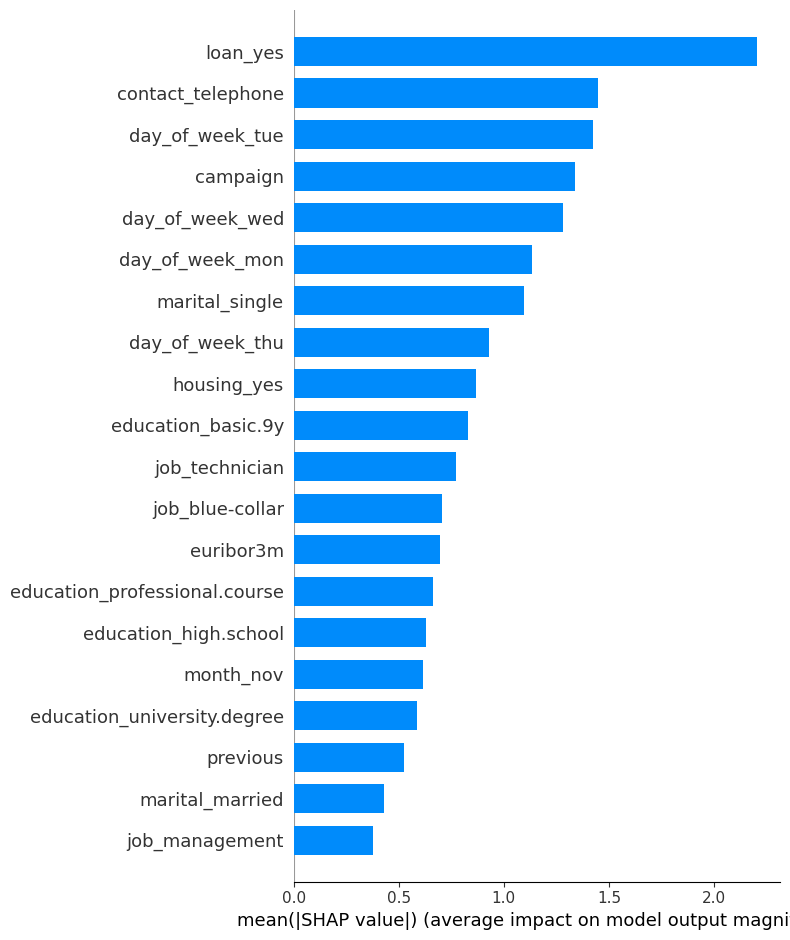

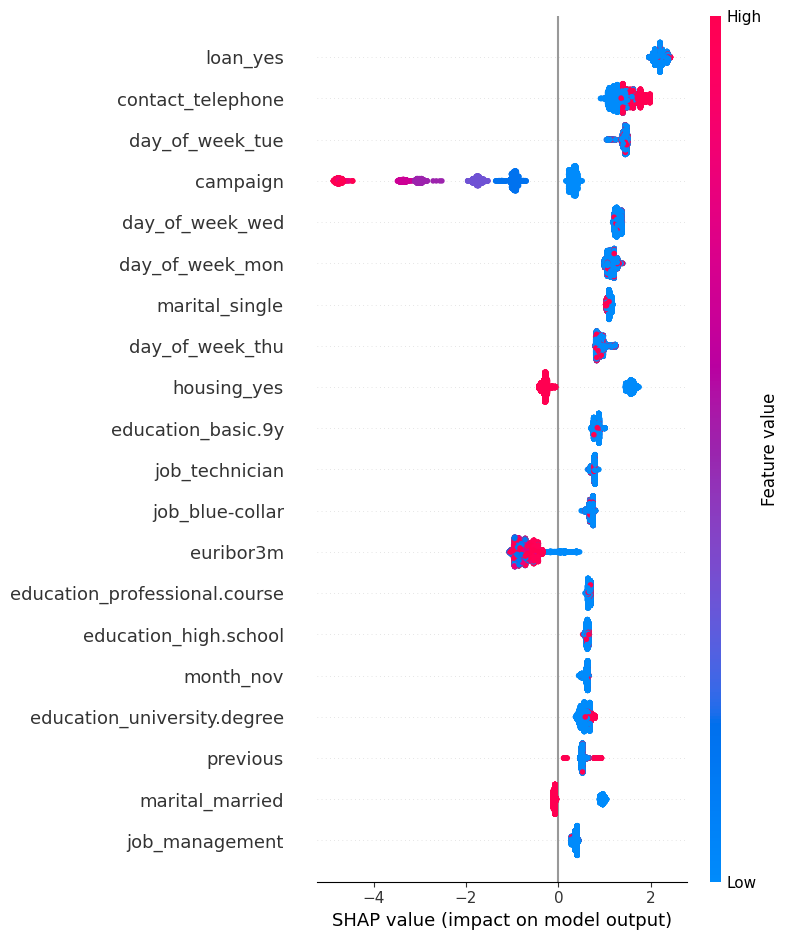

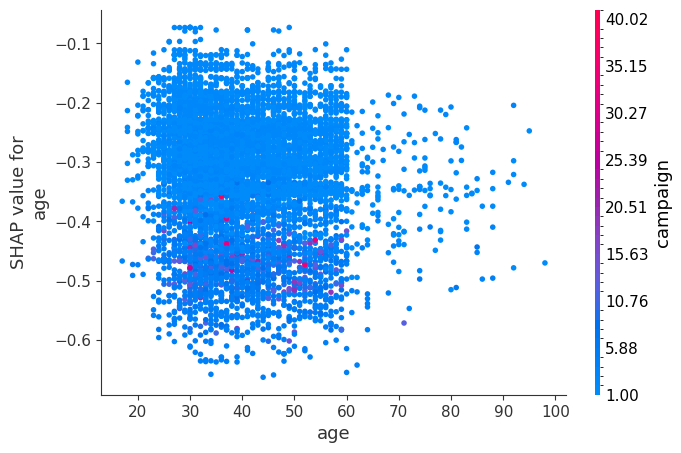

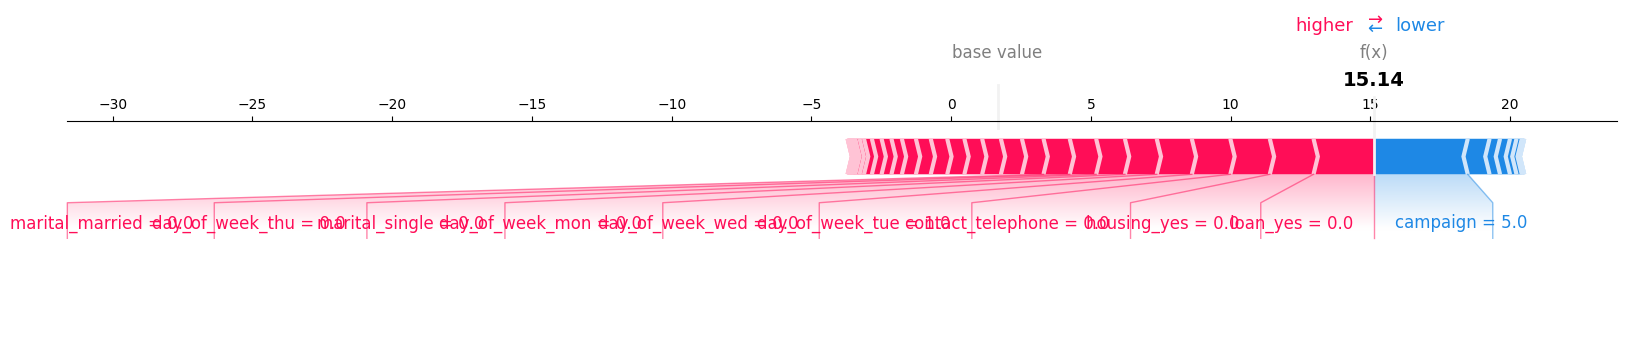

In [31]:
# ==============================
# SHAP EXPLAINABILITY (LightGBM FINAL)
# ==============================

print("\n--- SHAP EXPLANATION (LightGBM) ---")

import shap
import numpy as np

# Explainer
explainer = shap.TreeExplainer(best_lgb)

# SHAP values
shap_values = explainer.shap_values(X_test)

# ✅ Handle classification (binary)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# ✅ Ensure 2D shape
if len(shap_values_class1.shape) == 1:
    shap_values_class1 = shap_values_class1.reshape(1, -1)

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY
# -------------------------------
shap.summary_plot(shap_values_class1, X_test)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
shap.dependence_plot(
    X_test.columns[0],
    shap_values_class1,
    X_test
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

shap.force_plot(
    base_value,
    shap_values_class1[0],
    X_test.iloc[0],
    matplotlib=True
)

# **XGBoost**

In [32]:
from xgboost import XGBClassifier

In [33]:
#Hyperparameter Tuning

# ==============================
# XGBOOST TUNING
# ==============================
params_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0]
}

rscv_xgb = RandomizedSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    params_xgb,
    n_iter=10,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

rscv_xgb.fit(X_train_ad, y_train_ad)

best_xgb = rscv_xgb.best_estimator_

In [34]:
print("\n⚡ XGBoost (Tuned)")

y_pred_xgb = best_xgb.predict(X_test_scaled)
y_prob_xgb = best_xgb.predict_proba(X_test_scaled)[:,1]

compute_metrics(y_test, y_pred_xgb, y_prob_xgb)

print("Best Params (XGB):", rscv_xgb.best_params_)


⚡ XGBoost (Tuned)
Accuracy    : 0.9009
Precision   : 0.6138
Recall      : 0.3254
Specificity : 0.9740
F1 Score    : 0.4254
ROC-AUC     : 0.8032
MCC         : 0.3995
G-Mean      : 0.5630
Kappa       : 0.3767
Best Params (XGB): {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}


In [35]:
results_xgb = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train_f, X_test_f = X.iloc[train_idx], X.iloc[test_idx]
    y_train_f, y_test_f = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train_f = scaler.fit_transform(X_train_f)
    X_test_f  = scaler.transform(X_test_f)

    # ADASYN
    adasyn = ADASYN(random_state=42)
    X_train_f, y_train_f = adasyn.fit_resample(X_train_f, y_train_f)

    # Train
    start_time = time.time()
    best_xgb.fit(X_train_f, y_train_f)
    training_time = time.time() - start_time

    # Predict
    y_pred = best_xgb.predict(X_test_f)
    y_prob = best_xgb.predict_proba(X_test_f)[:,1]

    # Metrics
    acc = accuracy_score(y_test_f, y_pred)
    prec = precision_score(y_test_f, y_pred, zero_division=0)
    rec = recall_score(y_test_f, y_pred, zero_division=0)
    f1 = f1_score(y_test_f, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test_f, y_pred).ravel()

    specificity = tn/(tn+fp)
    fpr = fp/(fp+tn)
    gm = np.sqrt(rec * specificity)

    auc = roc_auc_score(y_test_f, y_prob)
    mcc = matthews_corrcoef(y_test_f, y_pred)
    kappa = cohen_kappa_score(y_test_f, y_pred)
    balanced_acc = (rec + specificity)/2

    results_xgb.append({
        "Fold": fold+1,
        "Classifier": "XGBoost",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

In [36]:
df_xgb = pd.DataFrame(results_xgb)

final_df = pd.concat([ df_xgb])

In [37]:
print("\n===== ALL MODELS =====")
print(final_df.to_string(index=False))

print("\n===== AVERAGE COMPARISON =====")
print(final_df.groupby("Classifier").mean(numeric_only=True))


===== ALL MODELS =====
 Fold Classifier  Accuracy  Precision   Recall  Specificity       F1       GM      FPR      AUC      MCC    Kappa  Balanced Accuracy  Training Time (s)
    1    XGBoost  0.896820   0.574144 0.325431     0.969357 0.415406 0.561657 0.030643 0.784563 0.381212 0.363531           0.647394          17.198100
    2    XGBoost  0.891479   0.537445 0.262931     0.971272 0.353111 0.505349 0.028728 0.779531 0.324486 0.301407           0.617102           7.548377
    3    XGBoost  0.891964   0.537549 0.293103     0.967989 0.379358 0.532655 0.032011 0.791821 0.343800 0.325757           0.630546           2.742138
    4    XGBoost  0.896577   0.570370 0.331897     0.968263 0.419619 0.566889 0.031737 0.775680 0.383441 0.367173           0.650080           4.290770
    5    XGBoost  0.901432   0.604317 0.362069     0.969904 0.452830 0.592598 0.030096 0.807055 0.418371 0.402385           0.665987           3.560597
    6    XGBoost  0.903375   0.622222 0.362069     0.972093 0.45


--- SHAP EXPLANATION (XGBoost) ---


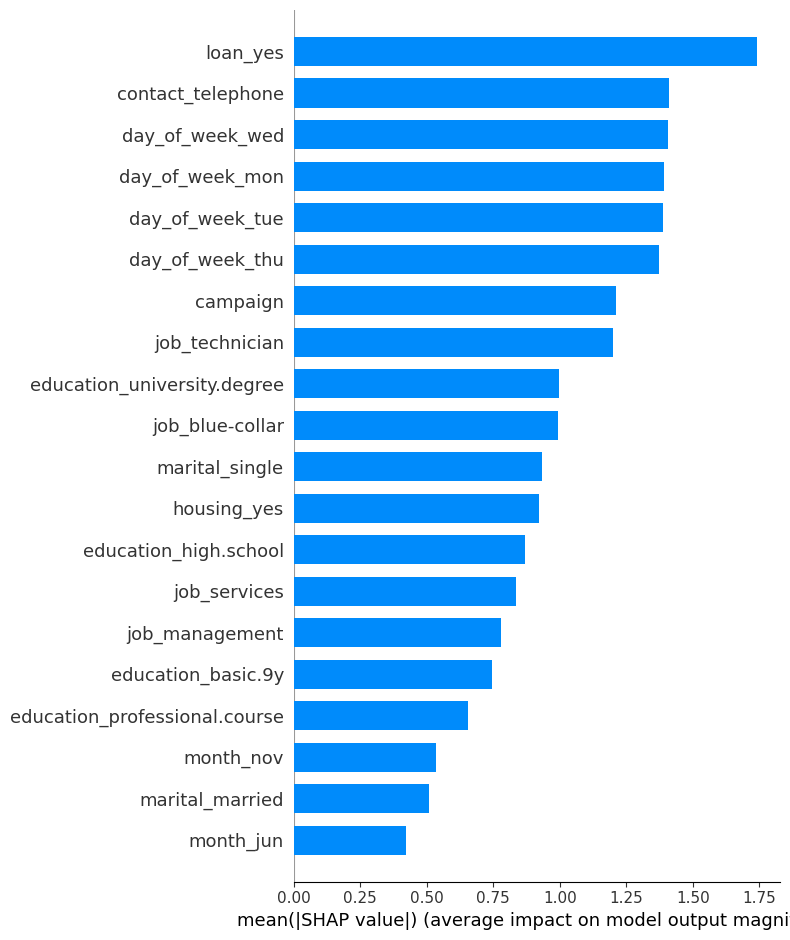

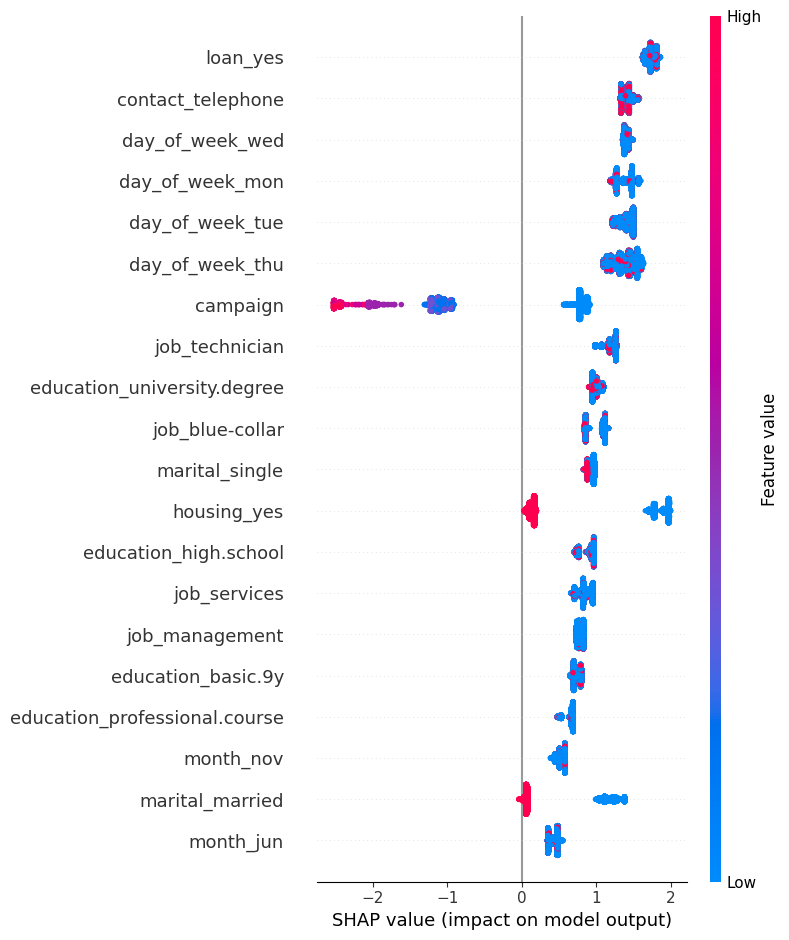

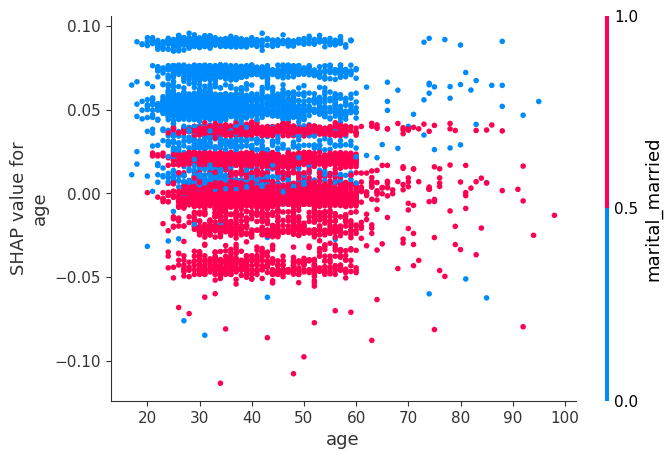

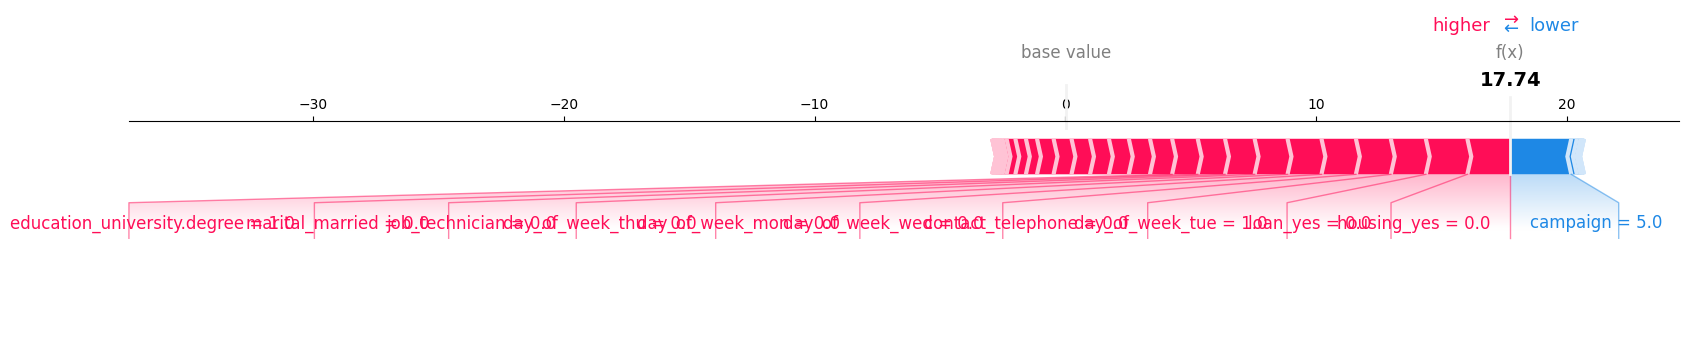

In [39]:
# ==============================
# SHAP EXPLANATION (XGBOOST FIXED)
# ==============================

print("\n--- SHAP EXPLANATION (XGBoost) ---")

import shap
import numpy as np

# Explainer
explainer = shap.TreeExplainer(best_xgb)

# SHAP values
shap_values = explainer.shap_values(X_test)

# ✅ Handle classification
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# ✅ Ensure correct shape
if len(shap_values_class1.shape) == 1:
    shap_values_class1 = shap_values_class1.reshape(1, -1)

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY
# -------------------------------
shap.summary_plot(shap_values_class1, X_test)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
shap.dependence_plot(
    X_test.columns[0],
    shap_values_class1,
    X_test
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

shap.force_plot(
    base_value,
    shap_values_class1[0],
    X_test.iloc[0],
    matplotlib=True
)

# Gradient Boosting (GBM)

In [56]:
#Import GBM

from sklearn.ensemble import GradientBoostingClassifier

In [57]:
#Hyperparameter Tuning

# ==============================
# GRADIENT BOOSTING TUNING
# ==============================
params_gbm = {
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1],
    "max_depth": [3, 5],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

rscv_gbm = RandomizedSearchCV(
    GradientBoostingClassifier(),
    params_gbm,
    n_iter=5,
    scoring='f1',
    cv=3,
    n_jobs=-1
)

rscv_gbm.fit(X_train_ad, y_train_ad)

best_gbm = rscv_gbm.best_estimator_

In [58]:
#Test Performance

print("\n Gradient Boosting (Tuned)")

y_pred_gbm = best_gbm.predict(X_test_scaled)
y_prob_gbm = best_gbm.predict_proba(X_test_scaled)[:,1]

compute_metrics(y_test, y_pred_gbm, y_prob_gbm)

print("Best Params (GBM):", rscv_gbm.best_params_)


 Gradient Boosting (Tuned)
Accuracy    : 0.9006
Precision   : 0.6079
Recall      : 0.3308
Specificity : 0.9729
F1 Score    : 0.4285
ROC-AUC     : 0.8044
MCC         : 0.4003
G-Mean      : 0.5673
Kappa       : 0.3792
Best Params (GBM): {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.1}


In [59]:
#Cross Validation (GBM)

results_gbm = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):

    X_train_f, X_test_f = X.iloc[train_idx], X.iloc[test_idx]
    y_train_f, y_test_f = y.iloc[train_idx], y.iloc[test_idx]

    # Scaling
    scaler = StandardScaler()
    X_train_f = scaler.fit_transform(X_train_f)
    X_test_f  = scaler.transform(X_test_f)

    # ADASYN
    adasyn = ADASYN(random_state=42)
    X_train_f, y_train_f = adasyn.fit_resample(X_train_f, y_train_f)

    # Train
    start_time = time.time()
    best_gbm.fit(X_train_f, y_train_f)
    training_time = time.time() - start_time

    # Predict
    y_pred = best_gbm.predict(X_test_f)
    y_prob = best_gbm.predict_proba(X_test_f)[:,1]

    # Metrics
    acc = accuracy_score(y_test_f, y_pred)
    prec = precision_score(y_test_f, y_pred, zero_division=0)
    rec = recall_score(y_test_f, y_pred, zero_division=0)
    f1 = f1_score(y_test_f, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_test_f, y_pred).ravel()

    specificity = tn/(tn+fp)
    fpr = fp/(fp+tn)
    gm = np.sqrt(rec * specificity)

    auc = roc_auc_score(y_test_f, y_prob)
    mcc = matthews_corrcoef(y_test_f, y_pred)
    kappa = cohen_kappa_score(y_test_f, y_pred)
    balanced_acc = (rec + specificity)/2

    results_gbm.append({
        "Fold": fold+1,
        "Classifier": "Gradient Boosting",
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "Specificity": specificity,
        "F1": f1,
        "GM": gm,
        "FPR": fpr,
        "AUC": auc,
        "MCC": mcc,
        "Kappa": kappa,
        "Balanced Accuracy": balanced_acc,
        "Training Time (s)": training_time
    })

In [60]:
df_gbm = pd.DataFrame(results_gbm)

final_df = pd.concat([df_gbm])

In [61]:
#Print Comparison

print("\n===== GBM MODELS =====")
print(final_df.to_string(index=False))

print("\n===== AVERAGE COMPARISON =====")
print(final_df.groupby("Classifier").mean(numeric_only=True))


===== GBM MODELS =====
 Fold        Classifier  Accuracy  Precision   Recall  Specificity       F1       GM      FPR      AUC      MCC    Kappa  Balanced Accuracy  Training Time (s)
    1 Gradient Boosting  0.895606   0.563433 0.325431     0.967989 0.412568 0.561261 0.032011 0.788617 0.376130 0.359757           0.646710          85.909398
    2 Gradient Boosting  0.894149   0.561404 0.275862     0.972640 0.369942 0.517991 0.027360 0.781083 0.343586 0.319422           0.624251          86.106445
    3 Gradient Boosting  0.891236   0.530769 0.297414     0.966621 0.381215 0.536178 0.033379 0.794072 0.343273 0.326744           0.632017          87.228647
    4 Gradient Boosting  0.898276   0.584906 0.334052     0.969904 0.425240 0.569208 0.030096 0.779622 0.391683 0.373969           0.651978          88.100206
    5 Gradient Boosting  0.900947   0.601449 0.357759     0.969904 0.448649 0.589060 0.030096 0.808637 0.414324 0.398068           0.663831         101.785532
    6 Gradient Boostin


--- SHAP EXPLANATION (GBM) ---


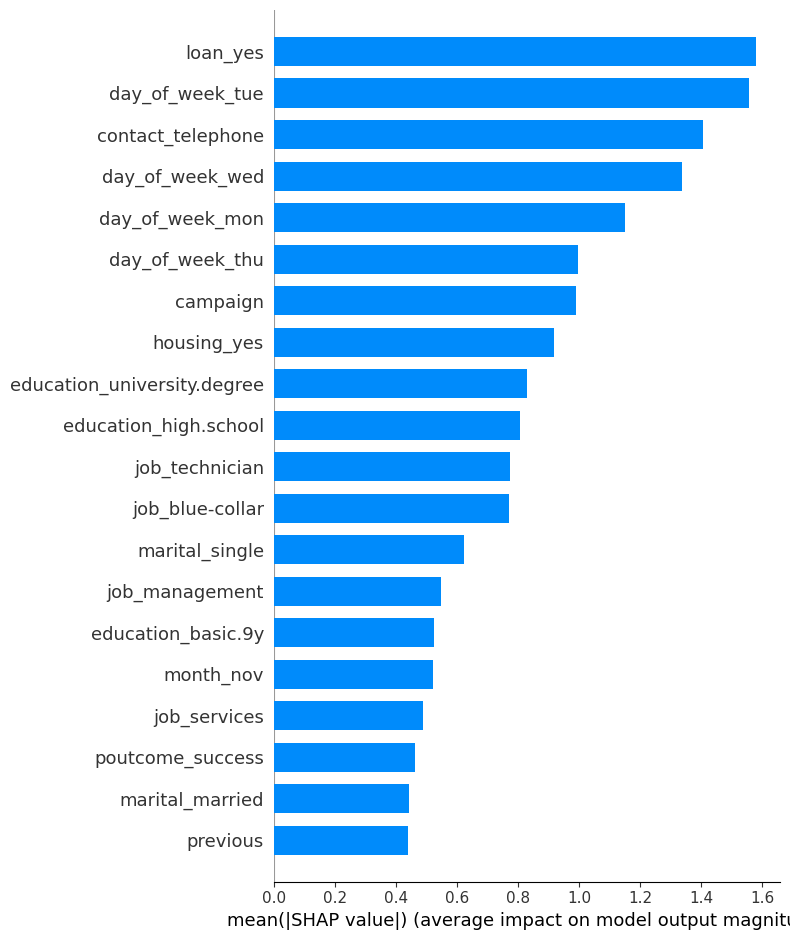

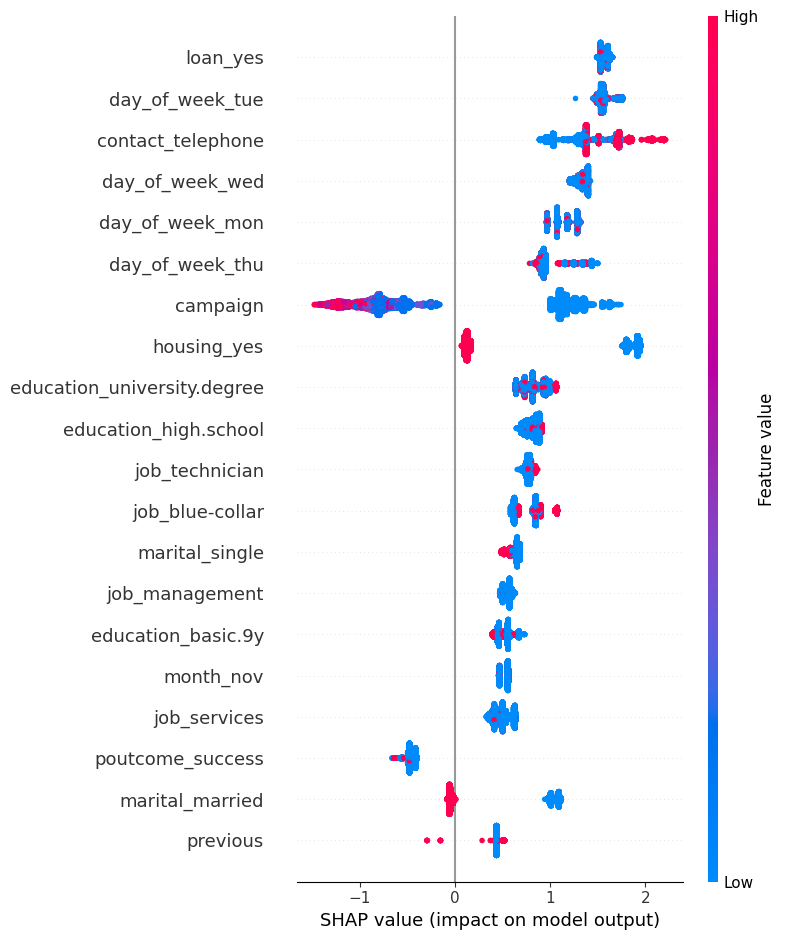

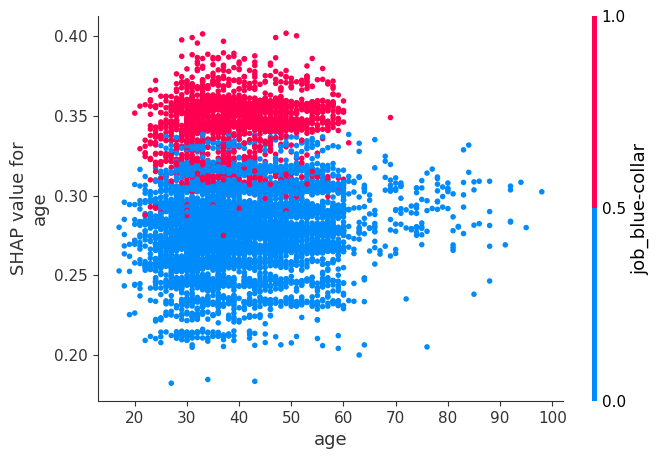

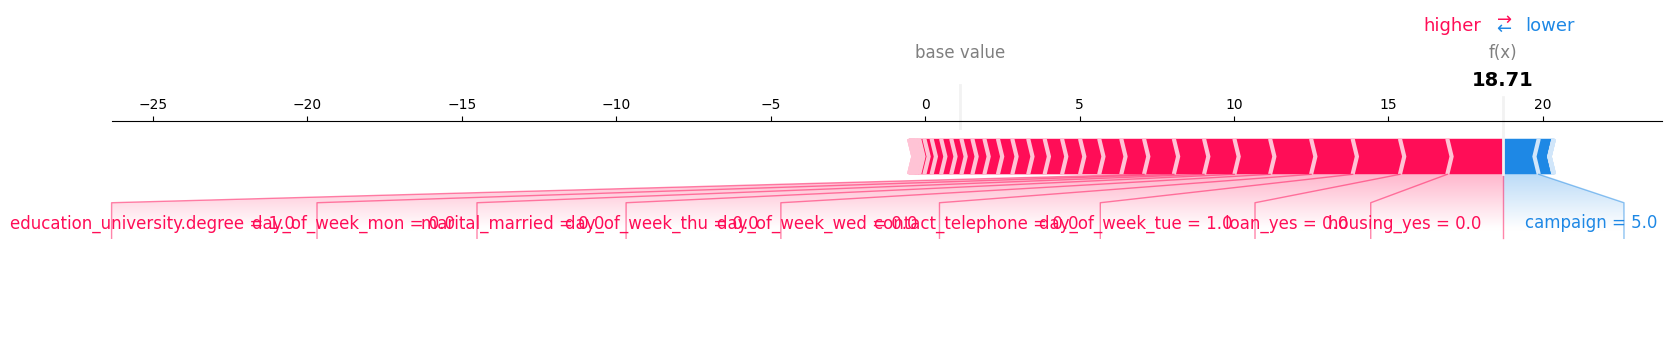

In [63]:
# ==============================
# SHAP EXPLANATION (GBM FINAL)
# ==============================

print("\n--- SHAP EXPLANATION (GBM) ---")

import shap
import numpy as np

# Explainer
explainer = shap.TreeExplainer(best_gbm)

# SHAP values
shap_values = explainer.shap_values(X_test)

# ✅ Handle classification (binary)
if isinstance(shap_values, list):
    shap_values_class1 = shap_values[1]
else:
    shap_values_class1 = shap_values

# ✅ Ensure 2D
if len(shap_values_class1.shape) == 1:
    shap_values_class1 = shap_values_class1.reshape(1, -1)

# -------------------------------
# 1. GLOBAL FEATURE IMPORTANCE
# -------------------------------
shap.summary_plot(shap_values_class1, X_test, plot_type="bar")

# -------------------------------
# 2. DETAILED SUMMARY
# -------------------------------
shap.summary_plot(shap_values_class1, X_test)

# -------------------------------
# 3. DEPENDENCE PLOT
# -------------------------------
shap.dependence_plot(
    X_test.columns[0],
    shap_values_class1,
    X_test
)

# -------------------------------
# 4. LOCAL EXPLANATION (FORCE PLOT)
# -------------------------------
base_value = explainer.expected_value
if isinstance(base_value, list):
    base_value = base_value[1]

shap.force_plot(
    base_value,
    shap_values_class1[0],
    X_test.iloc[0],
    matplotlib=True
)